<a href="https://colab.research.google.com/github/Utsav248/Utsav_Jarga_Magar_2408957_AIML/blob/main/Tut7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


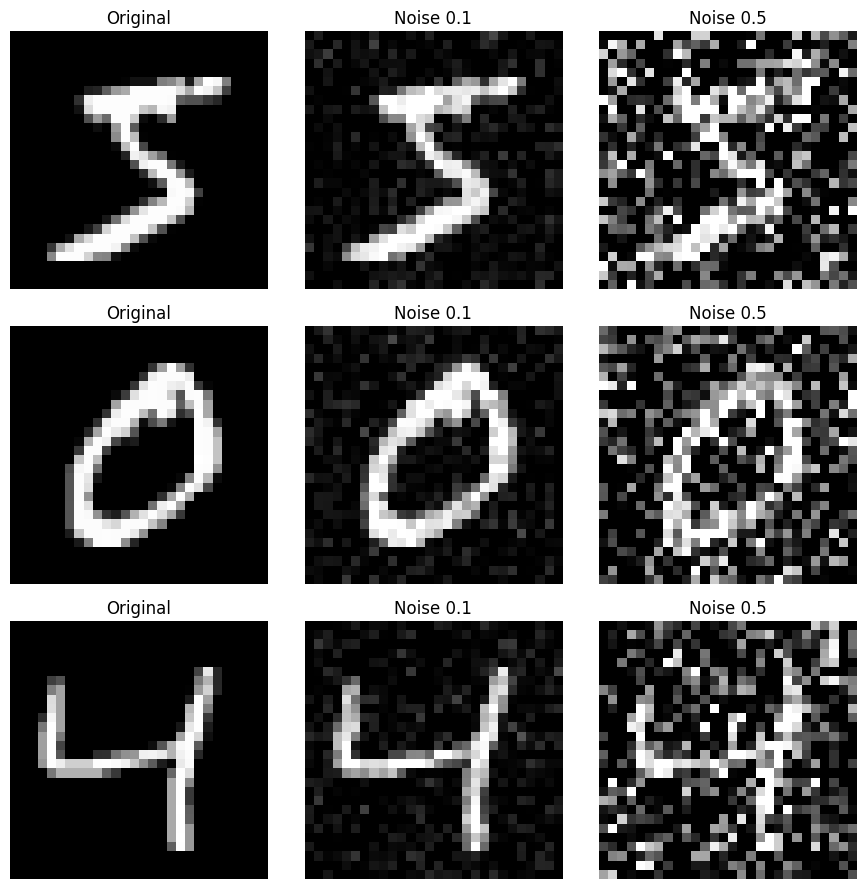

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

# Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
    # Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    # High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.
    """
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded

def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.
    """
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded

def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder.
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

# Compile and display the model summary
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()
# Train with noisy input and clean target
history = autoencoder.fit(
x_train_noisy_high, x_train,
epochs=10,
batch_size=128,
shuffle=True,
validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 196s 411ms/step - loss: 0.1550 - val_loss: 0.1126
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 193s 392ms/step - loss: 0.1099 - val_loss: 0.1052
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 207s 403ms/step - loss: 0.1047 - val_loss: 0.1026
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 172s 367ms/step - loss: 0.1021 - val_loss: 0.1005
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 176s 375ms/step - loss: 0.1002 - val_loss: 0.0989
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 371ms/step - loss: 0.0989 - val_loss: 0.0976
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 197s 360ms/step - loss: 0.0978 - val_loss: 0.0969
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 214s 386ms/step - loss: 0.0970 - val_loss: 0.0960
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 185s 394ms/step - loss: 0.0963 - val_loss: 0.0954
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 178s 380ms/step - loss: 0.0959 - val_loss: 0.0956


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step


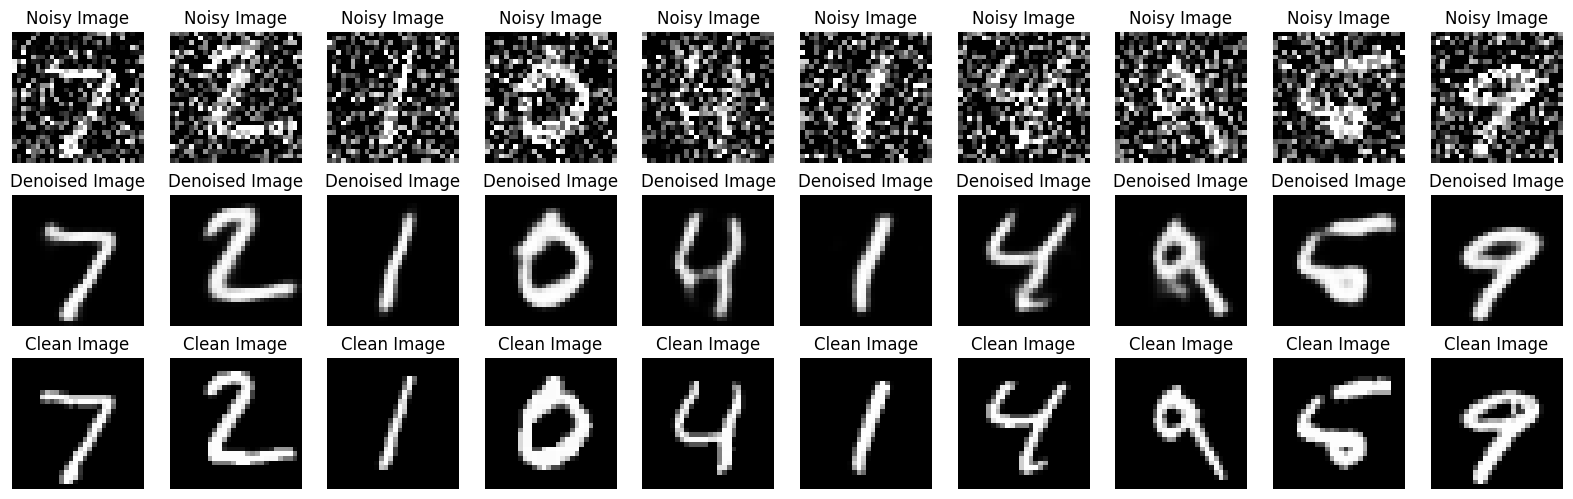

In [13]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')

        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')

        # Plot clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')
    plt.show()

# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

# 4 Exercise: Devanagari Handwritten Digit Denoising

### Step 1: Dataset Preparation and Preprocessing
We will use a subset of the Devanagari dataset, normalize it, and add noise.

In [18]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def load_devanagari_data(data_dir, img_size=(32, 32)):
    images = []
    if not os.path.exists(data_dir):
        return np.array([])
    for root, dirs, files in os.walk(data_dir):
        for file in files[:5000]:
            if file.endswith(('.png', '.jpg', '.jpeg')):
                img = Image.open(os.path.join(root, file)).convert('L')
                img = img.resize(img_size)
                images.append(np.asarray(img))
    if not images:
        return np.array([])
    x = np.array(images).astype('float32') / 255.
    x = np.reshape(x, (len(x), img_size[0], img_size[1], 1))
    return x

# Attempt to load or generate dummy data
x_devanagari = load_devanagari_data('/content/drive/MyDrive/Colab Notebooks_FY/AIML/Dataset/DevanagariHandwrittenDigitDataset')

if x_devanagari.size == 0:
    print("Dataset path not found or empty. Generating dummy Devanagari-like data...")
    x_devanagari = np.random.rand(1000, 32, 32, 1).astype('float32')

# Split and add noise
x_train_dev, x_test_dev = train_test_split(x_devanagari, test_size=0.2, random_state=42)
noise_factor = 0.4
x_train_noisy = np.clip(x_train_dev + noise_factor * np.random.normal(0, 1, x_train_dev.shape), 0, 1)
x_test_noisy = np.clip(x_test_dev + noise_factor * np.random.normal(0, 1, x_test_dev.shape), 0, 1)

### Step 2: Build a 4-Layer Deep Denoising Autoencoder

In [19]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization
from tensorflow.keras.models import Model

def build_deep_autoencoder(input_shape=(32, 32, 1)):
    # Encoder (4 Layers Deep)
    input_img = Input(shape=input_shape)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder (Matching 4 Layers)
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    return autoencoder

deep_autoencoder = build_deep_autoencoder()
deep_autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,761 (194.38 KB)

 Trainable params: 49,761 (194.38 KB)

 Non-trainable params: 0 (0.00 B)

### Step 3 & 4: Training and Evaluation
Training the model and visualizing the result.

Epoch 1/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 48s 418ms/step - loss: 0.4053 - val_loss: 0.2664
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 76s 358ms/step - loss: 0.2420 - val_loss: 0.2256
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 42s 366ms/step - loss: 0.2161 - val_loss: 0.2087
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 37s 333ms/step - loss: 0.2014 - val_loss: 0.1966
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 42s 342ms/step - loss: 0.1929 - val_loss: 0.1886
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 36s 339ms/step - loss: 0.1868 - val_loss: 0.1852
Epoch 7/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 38s 355ms/step - loss: 0.1824 - val_loss: 0.1794
Epoch 8/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 342ms/step - loss: 0.1786 - val_loss: 0.1769
Epoch 9/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 38s 362ms/step - loss: 0.1761 - val_loss: 0.1745
Epoch 10/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 37s 349ms/step - loss: 0.1732 - val_loss: 0.1722
Epoch 11/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 38s 361ms/step - loss: 0.1713 - val_loss: 0.1702
Epoch 12/20
106/106

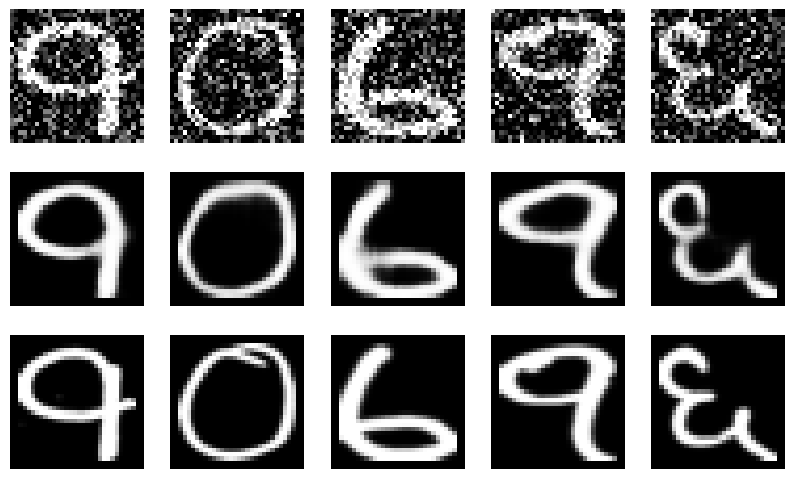

In [20]:
history = deep_autoencoder.fit(
    x_train_noisy, x_train_dev,
    epochs=20,
    batch_size=64,
    validation_data=(x_test_noisy, x_test_dev),
    verbose=1
)

# Visualization
denoised_imgs = deep_autoencoder.predict(x_test_noisy)

n = 5
plt.figure(figsize=(10, 6))
for i in range(n):
    # Noisy
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(32, 32), cmap='gray')
    plt.axis('off')
    # Denoised
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_imgs[i].reshape(32, 32), cmap='gray')
    plt.axis('off')
    # Original
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_test_dev[i].reshape(32, 32), cmap='gray')
    plt.axis('off')
plt.show()